In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_manual_roc(y_true, y_probs, thresholds_to_label=[0.2, 0.5, 0.8]):
    """
    Plots an ROC curve and labels specific thresholds using only NumPy/Matplotlib.
    """
    fpr_list = []
    tpr_list = []
    
    # 1. Define a range of thresholds (e.g., 100 points between 0 and 1)
    thresholds = np.linspace(0, 1, 100)
    
    # Calculate Total Positives (P) and Negatives (N) once
    P = sum(y_true)
    N = len(y_true) - P

    # 2. Compute FPR and TPR for each threshold
    for t in thresholds:
        y_pred = (y_probs >= t).astype(int)
        
        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        
        tpr_list.append(tp / P)
        fpr_list.append(fp / N)

    # 3. Plotting with Matplotlib
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_list, tpr_list, color='blue', label='ROC Curve')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess') # Baseline

    # 4. Adding specific threshold labels
    for t_label in thresholds_to_label:
        # Find values at the closest threshold to your label
        idx = np.argmin(np.abs(thresholds - t_label))
        plt.scatter(fpr_list[idx], tpr_list[idx], color='red')
        plt.text(fpr_list[idx] + 0.02, tpr_list[idx] - 0.04, f"T={t_label:.2f}", color='red')

    plt.title("Manual ROC Curve with Thresholds")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Example Usage:
# y_true = np.array([0, 0, 1, 1])
# y_probs = np.array([0.1, 0.4, 0.35, 0.8])
# plot_manual_roc(y_true, y_probs)


In [ ]:
y_true = [0,1,0,1]
y_probs = [0,1,1,1]

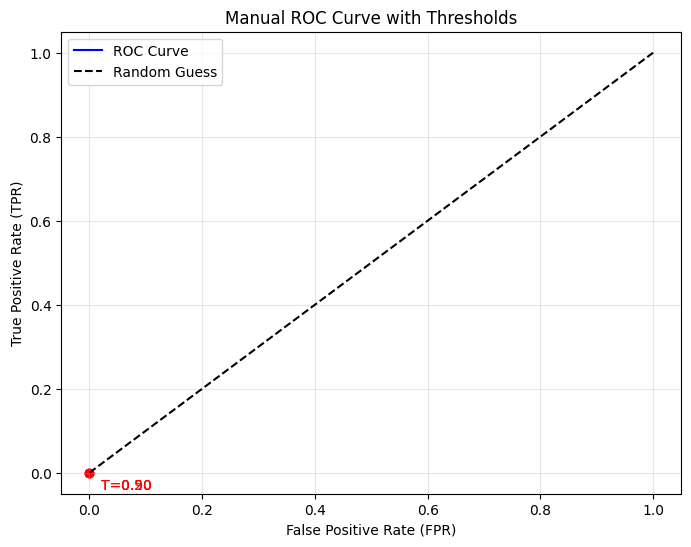

In [ ]:
plot_manual_roc(y_true, y_probs, thresholds_to_label=[0.2, 0.5, 0.9])

In [ ]:
import cv2
image = r"C:\Users\hp\Desktop\VS Code Projects\VS_AllCodes\Scratch - ANN\dataset\train\images\0--Parade\0_Parade_marchingband_1_5.jpg"
img = cv2.imread(image)
img_h, img_w = img.shape[:2]

In [ ]:
def load_yolo_gt_boxes(label_path, img_w, img_h):
    gt_boxes = []

    with open(label_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            cls, xc, yc, w, h = map(float, line.split())

            x1 = (xc - w / 2) * img_w
            y1 = (yc - h / 2) * img_h
            x2 = (xc + w / 2) * img_w
            y2 = (yc + h / 2) * img_h

            gt_boxes.append([x1, y1, x2, y2])

    return gt_boxes


In [6]:
gt_label_path = r"C:\Users\hp\Desktop\VS Code Projects\VS_AllCodes\Scratch - ANN\dataset\train\labels\0--Parade\0_Parade_marchingband_1_5.txt"

gt_boxes = load_yolo_gt_boxes(gt_label_path, img_w, img_h)

In [7]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # or your fine-tuned weights

results = model(r"C:\Users\hp\Desktop\VS Code Projects\VS_AllCodes\Scratch - ANN\dataset\train\images\0--Parade\0_Parade_marchingband_1_5.jpg")

result = results[0]


image 1/1 C:\Users\hp\Desktop\VS Code Projects\VS_AllCodes\Scratch - ANN\dataset\train\images\0--Parade\0_Parade_marchingband_1_5.jpg: 448x640 13 persons, 1 umbrella, 1 kite, 130.9ms
Speed: 6.2ms preprocess, 130.9ms inference, 2.5ms postprocess per image at shape (1, 3, 448, 640)


In [8]:
def yolo_inference(model, image):
    """
    Run YOLO inference and extract boxes & scores.
    """
    results = model(image)
    result = results[0]

    if result.boxes is None:
        return [], []

    pred_boxes = result.boxes.xyxy.cpu().numpy().tolist()
    pred_scores = result.boxes.conf.cpu().numpy().tolist()

    print("pred_boxes", pred_boxes, "\npred_scores", pred_scores)
    return pred_boxes, pred_scores

# dataset = (r"C:\Users\hp\Desktop\VS Code Projects\VS_AllCodes\Scratch - ANN\dataset")

image = r"C:\Users\hp\Desktop\VS Code Projects\VS_AllCodes\Scratch - ANN\dataset\train\images\0--Parade\0_Parade_marchingband_1_5.jpg"

pred_boxes, pred_scores = yolo_inference(model, image)


image 1/1 C:\Users\hp\Desktop\VS Code Projects\VS_AllCodes\Scratch - ANN\dataset\train\images\0--Parade\0_Parade_marchingband_1_5.jpg: 448x640 13 persons, 1 umbrella, 1 kite, 86.1ms
Speed: 4.6ms preprocess, 86.1ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)
pred_boxes [[422.6424865722656, 168.29257202148438, 579.2662963867188, 641.7911987304688], [182.72012329101562, 190.6527862548828, 298.53472900390625, 602.7459716796875], [559.8349609375, 173.3100128173828, 682.0402221679688, 577.9409790039062], [743.3914184570312, 129.7002410888672, 873.7160034179688, 612.3138427734375], [0.0, 181.1069793701172, 100.30763244628906, 563.9121704101562], [914.087890625, 150.85556030273438, 1023.6409912109375, 643.294921875], [272.7701110839844, 177.2406463623047, 390.84405517578125, 613.3900146484375], [664.4152221679688, 169.31591796875, 768.86083984375, 588.6182861328125], [871.2540893554688, 139.2451171875, 995.8326416015625, 639.2235107421875], [99.01005554199219, 169.2953643


image 1/1 C:\Users\hp\Desktop\VS Code Projects\VS_AllCodes\Scratch - ANN\dataset\train\images\0--Parade\0_Parade_marchingband_1_5.jpg: 448x640 13 persons, 1 umbrella, 1 kite, 122.5ms
Speed: 7.4ms preprocess, 122.5ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 C:\Users\hp\Desktop\VS Code Projects\VS_AllCodes\Scratch - ANN\dataset\train\images\0--Parade\0_Parade_marchingband_1_5.jpg: 448x640 13 persons, 1 umbrella, 1 kite, 98.1ms
Speed: 4.1ms preprocess, 98.1ms inference, 2.1ms postprocess per image at shape (1, 3, 448, 640)
pred_boxes [[422.6424865722656, 168.29257202148438, 579.2662963867188, 641.7911987304688], [182.72012329101562, 190.6527862548828, 298.53472900390625, 602.7459716796875], [559.8349609375, 173.3100128173828, 682.0402221679688, 577.9409790039062], [743.3914184570312, 129.7002410888672, 873.7160034179688, 612.3138427734375], [0.0, 181.1069793701172, 100.30763244628906, 563.9121704101562], [914.087890625, 150.85556030273438, 1023.64099121

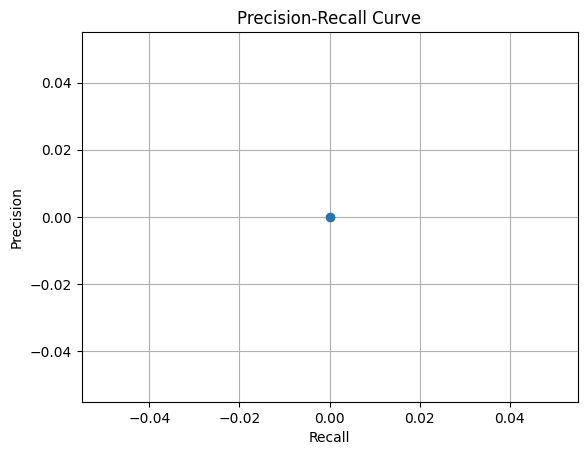

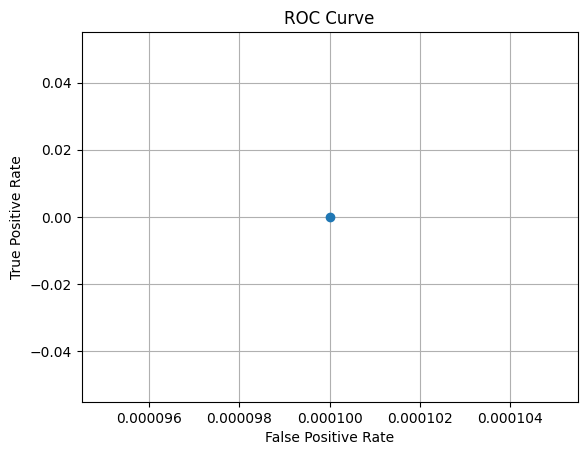

In [9]:
from evaluation_ import Evulation

results = model(image)
result = results[0]

eval = Evulation()
pred_boxes, pred_scores = yolo_inference(model, image)
results = model.predict(image, conf=0.4, verbose=False)
for r in results:
    if r.boxes is None:
        continue
    for box in r.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        w, h = x2 - x1, y2 - y1
# print("GT BOXES RAW:", gt_boxes)
# print("TYPE OF GT BOXES:", type(gt_boxes))
# print("FIRST GT BOX:", gt_boxes[0])
# print("TYPE OF FIRST GT BOX:", type(gt_boxes[0]))
# print("LENGTH OF FIRST GT BOX:", len(gt_boxes[0]))
TP, TN, FP, FN = eval.match_predication(pred_boxes, gt_boxes, threshold=0.5)
precision = eval.precision(TP, FP)
recall = eval.recall(TP, FN)
TPR, FPR = eval.compute_ROCcurve(TP, TN, FP, FN)
eval.plotPRcurve(recall, precision)
eval.plotROCcurve(TPR, FPR)